In [6]:
import pyspark.sql.functions as F

In [7]:
df = spark.read.table('datacollection.alpha_vantage.news_sentiment')

In [8]:
df.limit(2).show()

+--------------------+--------------------+-------------------+-------------+------------------+------------------+--------------------+-----------------------+-----------------------+--------------------+--------------------+--------------------+
|               title|                 url|     time_published|      authors|            source|     source_domain|             summary|overall_sentiment_score|overall_sentiment_label|              topics|    ticker_sentiment|        ingestion_ts|
+--------------------+--------------------+-------------------+-------------+------------------+------------------+--------------------+-----------------------+-----------------------+--------------------+--------------------+--------------------+
|Elbit signs deal ...|https://www.jpost...|2026-05-23 23:39:53|   UDI ETZION|The Jerusalem Post|The Jerusalem Post|Elbit Systems and...|               0.366356|                Bullish|[{manufacturing, ...|[{ESLT, 1.0, 0.44...|2026-05-24 22:21:...|
|Jim Cra

In [9]:
print(f"Shape: ({df.count()}, {len(df.columns)})")

Shape: (3266, 12)


In [10]:
df.printSchema()

root
 |-- title: string (nullable = true)
 |-- url: string (nullable = true)
 |-- time_published: timestamp (nullable = true)
 |-- authors: string (nullable = true)
 |-- source: string (nullable = true)
 |-- source_domain: string (nullable = true)
 |-- summary: string (nullable = true)
 |-- overall_sentiment_score: float (nullable = true)
 |-- overall_sentiment_label: string (nullable = true)
 |-- topics: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- topic: string (nullable = true)
 |    |    |-- relevance_score: float (nullable = true)
 |-- ticker_sentiment: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- ticker: string (nullable = true)
 |    |    |-- relevance_score: float (nullable = true)
 |    |    |-- ticker_sentiment_score: float (nullable = true)
 |    |    |-- ticker_sentiment_label: string (nullable = true)
 |-- ingestion_ts: timestamp (nullable = true)



In [11]:
df.select(F.min(F.col('ingestion_ts'))).collect()[0][0]

datetime.datetime(2026, 5, 24, 19, 21, 24, 573868)

In [12]:
df.select(F.max(F.col('ingestion_ts'))).collect()[0][0]

datetime.datetime(2026, 6, 26, 8, 0, 55, 605168)

In [13]:
df.select('summary').collect()[403][0]

"Vishay Intertechnology has expanded its IHXL series of inductors with new, lower-cost devices that boast improved efficiency and target demanding automotive, industrial, and renewable energy applications. This move reinforces Vishay's focus on components critical for electrification and power conversion, especially for EVs and clean energy systems. The company's investment narrative centers on its capacity build-out and power-electronics portfolio translating into healthier margins and steadier earnings, though near-term risks exist regarding capital spending and potential underutilization if demand disappoints."

# 2. EDA — Diagnóstico Descritivo

Seção dedicada ao diagnóstico descritivo do dataset: **volume temporal**, **qualidade dos dados**, **distribuição de sentimento**, **fontes** e **estrutura dos arrays aninhados**. É a base que fundamenta todas as análises subsequentes e expõe problemas de qualidade/ingestão.

## 2.1 Volume temporal e gaps de ingestão

Quantos artigos chegam por dia/semana? Há dias sem ingestão (possível falha do pipeline)?

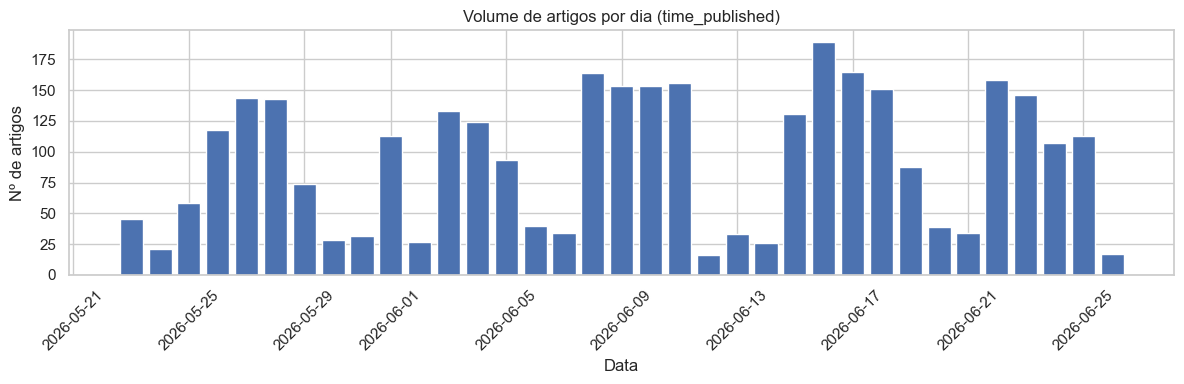

Janela observada: 2026-05-23 a 2026-06-26 (35 dias)
Dias com ingestão: 35 | Dias sem ingestão: 0


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 4)

# --- Volume diário ---
df_daily = (
    df.withColumn('publish_date', F.to_date('time_published'))
      .groupBy('publish_date')
      .agg(F.count('*').alias('artigos'))
      .orderBy('publish_date')
)
pdf_daily = df_daily.toPandas()

fig, ax = plt.subplots()
ax.bar(pdf_daily['publish_date'], pdf_daily['artigos'], color='#4C72B0')
ax.set_title('Volume de artigos por dia (time_published)')
ax.set_xlabel('Data'); ax.set_ylabel('Nº de artigos')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

# --- Gaps: datas sem nenhum artigo dentro da janela observada ---
date_min, date_max = pdf_daily['publish_date'].min(), pdf_daily['publish_date'].max()
all_dates = pd.date_range(date_min, date_max, freq='D')
missing = all_dates.difference(pd.to_datetime(pdf_daily['publish_date']))
print(f'Janela observada: {date_min} a {date_max} ({len(all_dates)} dias)')
print(f'Dias com ingestão: {len(pdf_daily)} | Dias sem ingestão: {len(missing)}')
if len(missing) > 0:
    print('Datas sem artigos:', list(missing.strftime('%Y-%m-%d')))

In [15]:
df.limit(2).show()

+--------------------+--------------------+-------------------+-------------+------------------+------------------+--------------------+-----------------------+-----------------------+--------------------+--------------------+--------------------+
|               title|                 url|     time_published|      authors|            source|     source_domain|             summary|overall_sentiment_score|overall_sentiment_label|              topics|    ticker_sentiment|        ingestion_ts|
+--------------------+--------------------+-------------------+-------------+------------------+------------------+--------------------+-----------------------+-----------------------+--------------------+--------------------+--------------------+
|Elbit signs deal ...|https://www.jpost...|2026-05-23 23:39:53|   UDI ETZION|The Jerusalem Post|The Jerusalem Post|Elbit Systems and...|               0.366356|                Bullish|[{manufacturing, ...|[{ESLT, 1.0, 0.44...|2026-05-24 22:21:...|
|Jim Cra

In [16]:
"""
# --- Volume semanal (média + total) ---
df_weekly = (
    df.withColumn('iso_week', F.date_format(F.weekofyear('time_published'), '02d'))
      .withColumn('year_week', F.concat_ws('-', F.year('time_published'), F.col('iso_week')))
      .groupBy('year_week')
      .agg(F.count('*').alias('artigos'))
      .orderBy('year_week')
)
pdf_weekly = df_weekly.toPandas()

fig, ax = plt.subplots()
ax.bar(pdf_weekly['year_week'], pdf_weekly['artigos'], color='#55A868')
ax.set_title('Volume de artigos por semana ISO')
ax.set_xlabel('Ano-Semana'); ax.set_ylabel('Nº de artigos')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()
"""

"\n# --- Volume semanal (média + total) ---\ndf_weekly = (\n    df.withColumn('iso_week', F.date_format(F.weekofyear('time_published'), '02d'))\n      .withColumn('year_week', F.concat_ws('-', F.year('time_published'), F.col('iso_week')))\n      .groupBy('year_week')\n      .agg(F.count('*').alias('artigos'))\n      .orderBy('year_week')\n)\npdf_weekly = df_weekly.toPandas()\n\nfig, ax = plt.subplots()\nax.bar(pdf_weekly['year_week'], pdf_weekly['artigos'], color='#55A868')\nax.set_title('Volume de artigos por semana ISO')\nax.set_xlabel('Ano-Semana'); ax.set_ylabel('Nº de artigos')\nax.tick_params(axis='x', rotation=45)\nplt.tight_layout(); plt.show()\n"

## 2.2 Qualidade dos dados — nulos e estrutura dos arrays

Cobertura de nulos por coluna (texto vs. numérico) e distribuição do tamanho dos arrays `topics` e `ticker_sentiment` (quantos tópicos/empresas por artigo).

/var/folders/m6/5gldbqjd7y97574965jjjdsw0000gn/T/ipykernel_31437/3538662849.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


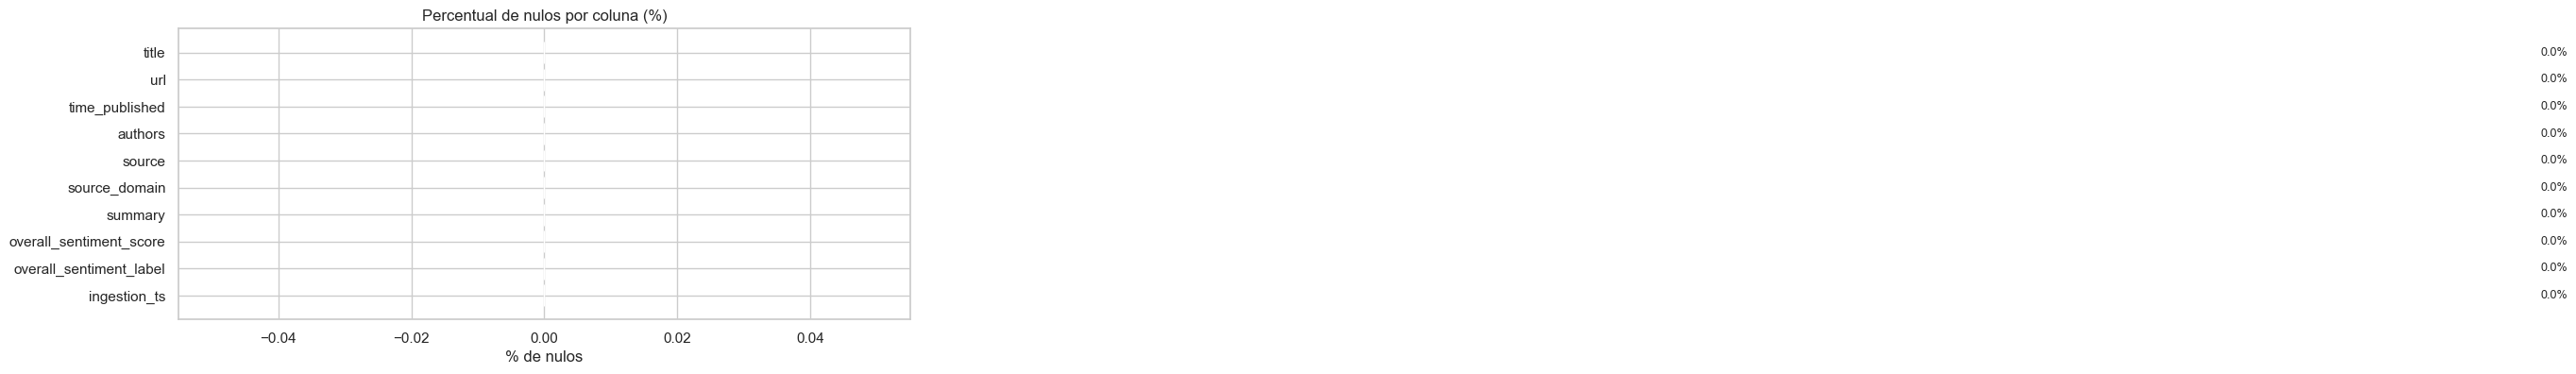

In [17]:
# --- Cobertura de nulos por coluna ---
cols = [c for c in df.columns if c not in ('topics', 'ticker_sentiment')]
null_pdf = df.select([
    (F.count(F.when(F.col(c).isNull(), c)) / F.count('*')).alias(c)
    for c in cols
]).toPandas().T.reset_index()
null_pdf.columns = ['coluna', 'pct_nulo']
null_pdf = null_pdf.sort_values('pct_nulo', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(null_pdf['coluna'], null_pdf['pct_nulo'] * 100, color='#C44E52')
ax.set_title('Percentual de nulos por coluna (%)')
ax.set_xlabel('% de nulos'); ax.invert_yaxis()
for i, v in enumerate(null_pdf['pct_nulo'] * 100):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout(); plt.show()

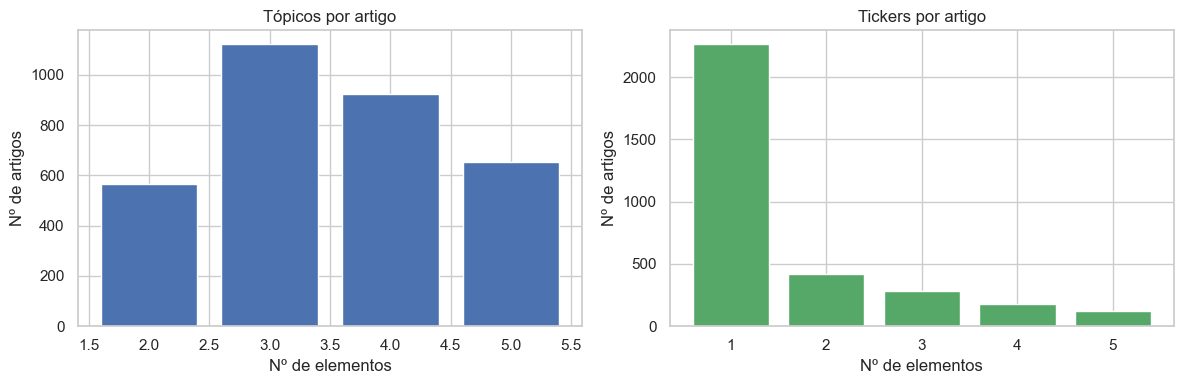

              Média  Mediana  Máx
n_topics   3.510104      3.0  5.0
n_tickers  1.618800      1.0  5.0


In [18]:
# --- Distribuição do tamanho dos arrays aninhados ---
df_sizes = df.select(
    F.size('topics').alias('n_topics'),
    F.size('ticker_sentiment').alias('n_tickers')
)
pdf_sizes = df_sizes.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title, color in [
    (axes[0], 'n_topics', 'Tópicos por artigo', '#4C72B0'),
    (axes[1], 'n_tickers', 'Tickers por artigo', '#55A868'),
]:
    counts = pdf_sizes[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color)
    ax.set_title(title); ax.set_xlabel('Nº de elementos'); ax.set_ylabel('Nº de artigos')
plt.tight_layout(); plt.show()

desc = pdf_sizes.describe().T[['mean', '50%', 'max']]
desc.columns = ['Média', 'Mediana', 'Máx']
print(desc.to_string())

## 2.3 Distribuição do sentimento

Distribuição do `overall_sentiment_label` (Bearish → Bullish) e histograma do `overall_sentiment_score` contínuo. Indica viés médio da cobertura noticiosa.

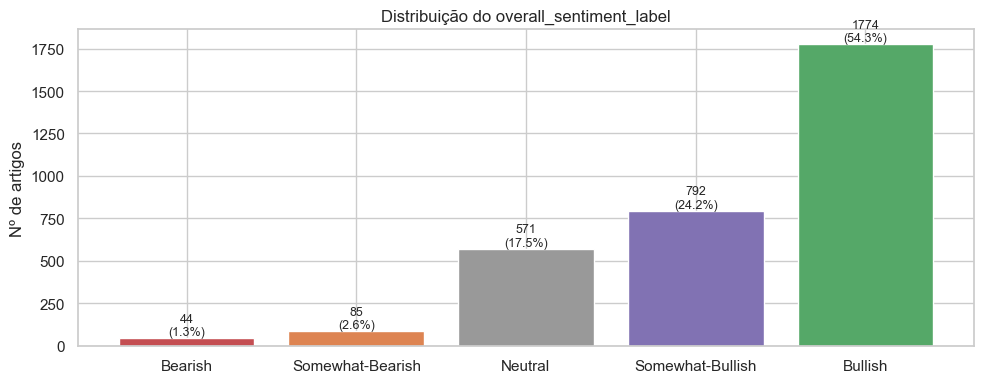

In [19]:
# --- Contagem e proporção por label ---
order_labels = ['Bearish', 'Somewhat-Bearish', 'Neutral', 'Somewhat-Bullish', 'Bullish']
pdf_label = df.groupBy('overall_sentiment_label').count().toPandas()
pdf_label['pct'] = pdf_label['count'] / pdf_label['count'].sum() * 100
pdf_label = pdf_label.set_index('overall_sentiment_label').reindex(order_labels).fillna(0).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#C44E52', '#DD8452', '#999999', '#8172B3', '#55A868']
ax.bar(pdf_label['overall_sentiment_label'], pdf_label['count'], color=colors)
ax.set_title('Distribuição do overall_sentiment_label')
ax.set_ylabel('Nº de artigos')
for i, (c, p) in enumerate(zip(pdf_label['count'], pdf_label['pct'])):
    ax.text(i, c + len(pdf_label)*0.005, f'{int(c)}\n({p:.1f}%)', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

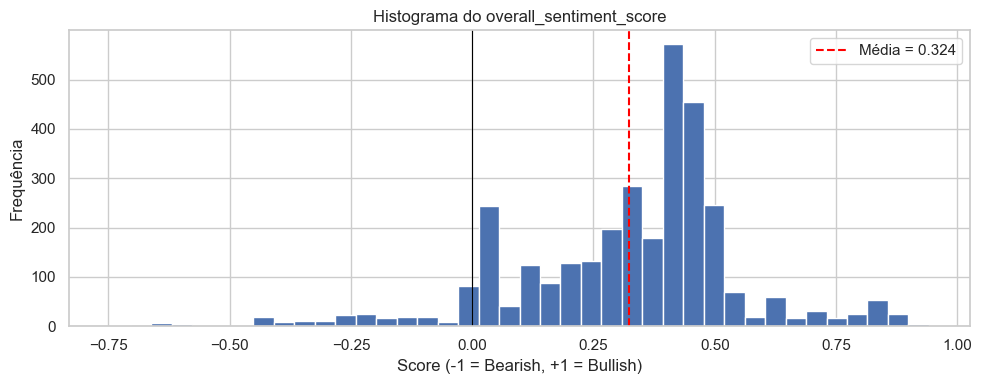

count    3266.000000
mean        0.324026
std         0.231478
min        -0.746113
25%         0.204970
50%         0.382891
75%         0.448337
max         0.941193


In [20]:
# --- Histograma do score contínuo ---
pdf_score = df.select('overall_sentiment_score').toPandas()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(pdf_score['overall_sentiment_score'], bins=40, color='#4C72B0', edgecolor='white')
ax.axvline(pdf_score['overall_sentiment_score'].mean(), color='red', ls='--', lw=1.5,
           label=f'Média = {pdf_score["overall_sentiment_score"].mean():.3f}')
ax.axvline(0, color='black', ls='-', lw=0.8)
ax.set_title('Histograma do overall_sentiment_score')
ax.set_xlabel('Score (-1 = Bearish, +1 = Bullish)'); ax.set_ylabel('Frequência')
ax.legend()
plt.tight_layout(); plt.show()

print(pdf_score['overall_sentiment_score'].describe().to_string())

## 2.4 Fontes e autores

Quais fontes (`source` / `source_domain`) e autores mais publicam? Mostra a concentração da cobertura.

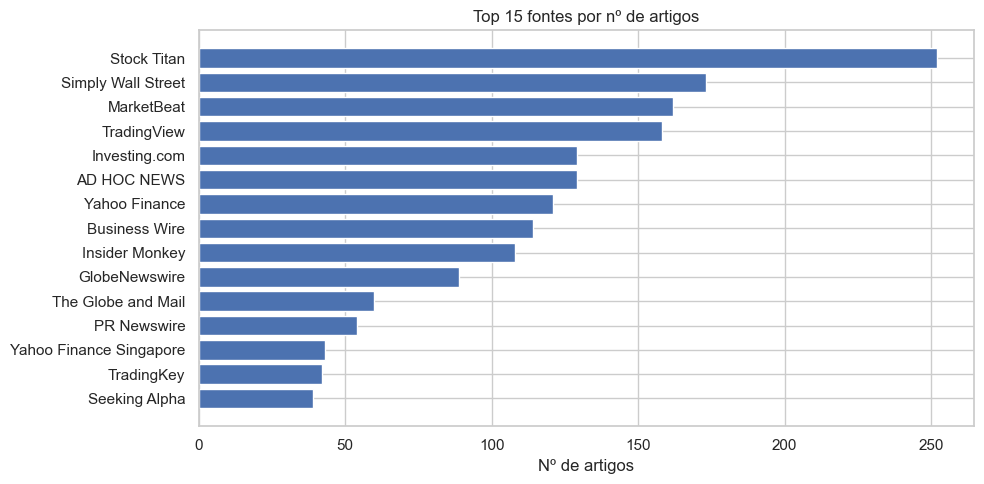

In [21]:
TOP_N = 15

# --- Top fontes ---
pdf_src = (df.groupBy('source').count().orderBy(F.desc('count')).limit(TOP_N).toPandas())

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(pdf_src['source'][::-1], pdf_src['count'][::-1], color='#4C72B0')
ax.set_title(f'Top {TOP_N} fontes por nº de artigos')
ax.set_xlabel('Nº de artigos')
plt.tight_layout(); plt.show()

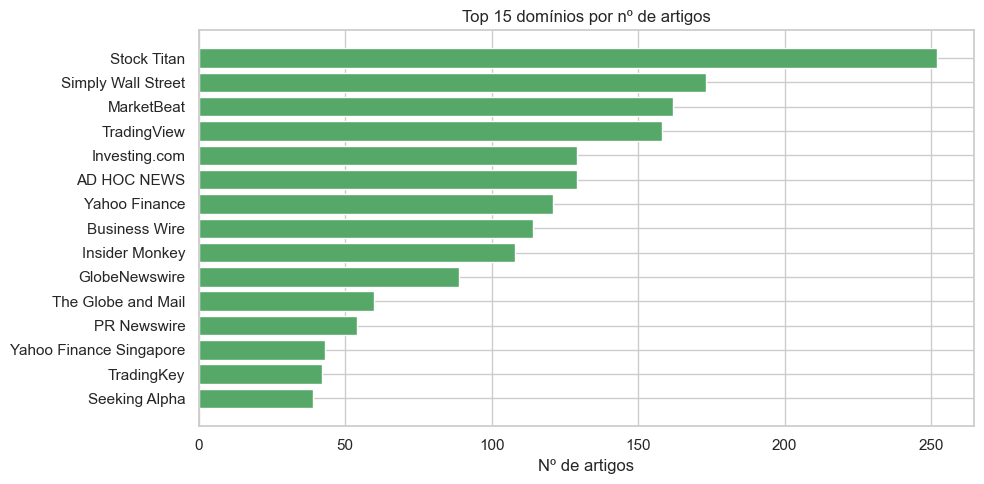

In [22]:
# --- Top domínios ---
pdf_dom = (df.groupBy('source_domain').count().orderBy(F.desc('count')).limit(TOP_N).toPandas())

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(pdf_dom['source_domain'][::-1], pdf_dom['count'][::-1], color='#55A868')
ax.set_title(f'Top {TOP_N} domínios por nº de artigos')
ax.set_xlabel('Nº de artigos')
plt.tight_layout(); plt.show()

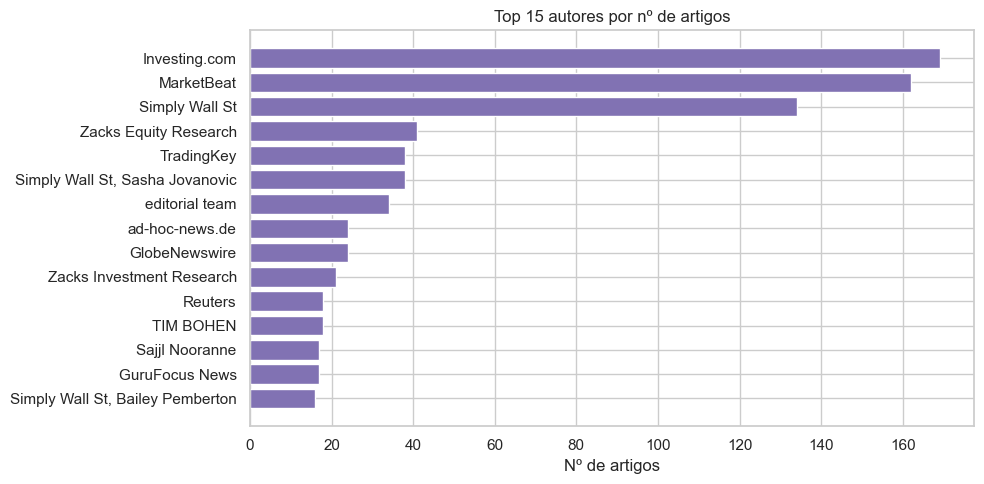

In [23]:
# --- Top autores (campo authors é string única com nomes separados por vírgula) ---
pdf_aut = (df.filter(F.col('authors') != '').groupBy('authors').count()
            .orderBy(F.desc('count')).limit(TOP_N).toPandas())

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(pdf_aut['authors'][::-1], pdf_aut['count'][::-1], color='#8172B3')
ax.set_title(f'Top {TOP_N} autores por nº de artigos')
ax.set_xlabel('Nº de artigos')
plt.tight_layout(); plt.show()

# 3. Séries Temporais

Análise da evolução temporal do sentimento, sazonalidade (dia da semana / hora do dia) e detecção de anomalias. Utiliza `statsmodels` para decomposição.

## 3.1 Sentimento médio diário

Evolução do `overall_sentiment_score` médio por dia com banda de ±1 desvio-padrão. Revela tendências e dias atípicos.

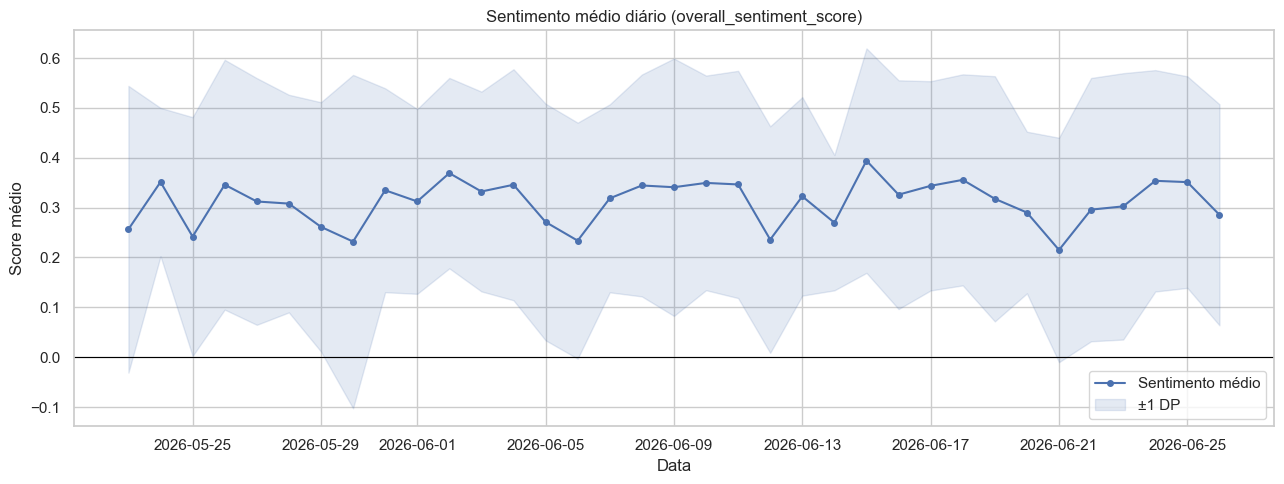

In [24]:
df_sent_daily = (
    df.withColumn('publish_date', F.to_date('time_published'))
      .groupBy('publish_date')
      .agg(
          F.avg('overall_sentiment_score').alias('sent_mean'),
          F.stddev('overall_sentiment_score').alias('sent_std'),
          F.count('*').alias('n')
      )
      .orderBy('publish_date')
)
pdf_sent = df_sent_daily.toPandas()
pdf_sent['publish_date'] = pd.to_datetime(pdf_sent['publish_date'])

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(pdf_sent['publish_date'], pdf_sent['sent_mean'], color='#4C72B0', marker='o', ms=4, label='Sentimento médio')
ax.fill_between(pdf_sent['publish_date'],
                pdf_sent['sent_mean'] - pdf_sent['sent_std'].fillna(0),
                pdf_sent['sent_mean'] + pdf_sent['sent_std'].fillna(0),
                color='#4C72B0', alpha=0.15, label='±1 DP')
ax.axhline(0, color='black', ls='-', lw=0.8)
ax.set_title('Sentimento médio diário (overall_sentiment_score)')
ax.set_xlabel('Data'); ax.set_ylabel('Score médio')
ax.legend()
plt.tight_layout(); plt.show()

## 3.2 Sazonalidade — dia da semana e hora do dia

Quando as notícias são publicadas? Existe padrão por dia da semana (seg-dom) ou hora do dia? O volume e o sentimento variam?

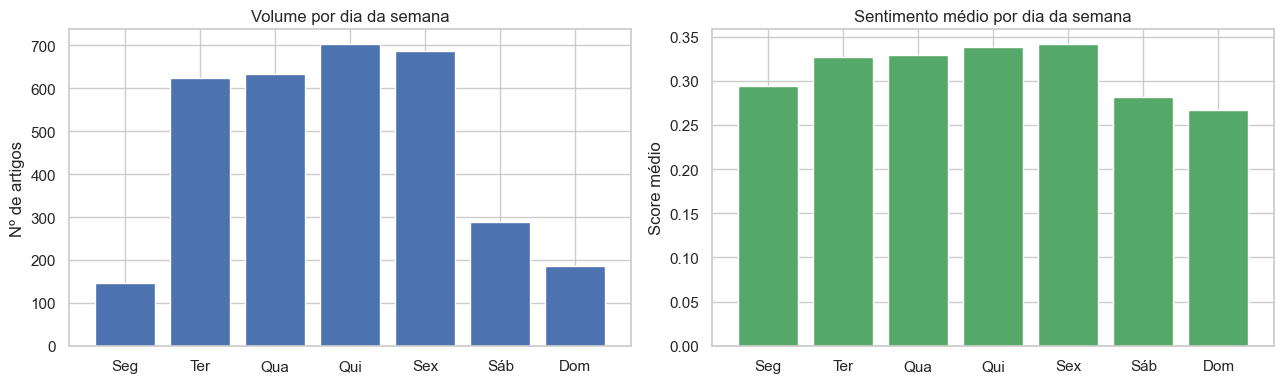

In [25]:
# --- Volume e sentimento por dia da semana ---
dow_names = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
df_dow = (
    df.withColumn('dow', F.dayofweek('time_published'))  # 1=domingo ... 7=sábado
      .withColumn('dow_idx', F.col('dow') - 1)  # 0..6
      .groupBy('dow_idx')
      .agg(F.count('*').alias('artigos'),
           F.avg('overall_sentiment_score').alias('sent_mean'))
      .orderBy('dow_idx')
)
pdf_dow = df_dow.toPandas()
pdf_dow['dia'] = [dow_names[int(i)] for i in pdf_dow['dow_idx']]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(pdf_dow['dia'], pdf_dow['artigos'], color='#4C72B0')
axes[0].set_title('Volume por dia da semana'); axes[0].set_ylabel('Nº de artigos')
axes[1].bar(pdf_dow['dia'], pdf_dow['sent_mean'], color='#55A868')
axes[1].set_title('Sentimento médio por dia da semana'); axes[1].set_ylabel('Score médio')
axes[1].axhline(0, color='black', lw=0.8)
plt.tight_layout(); plt.show()

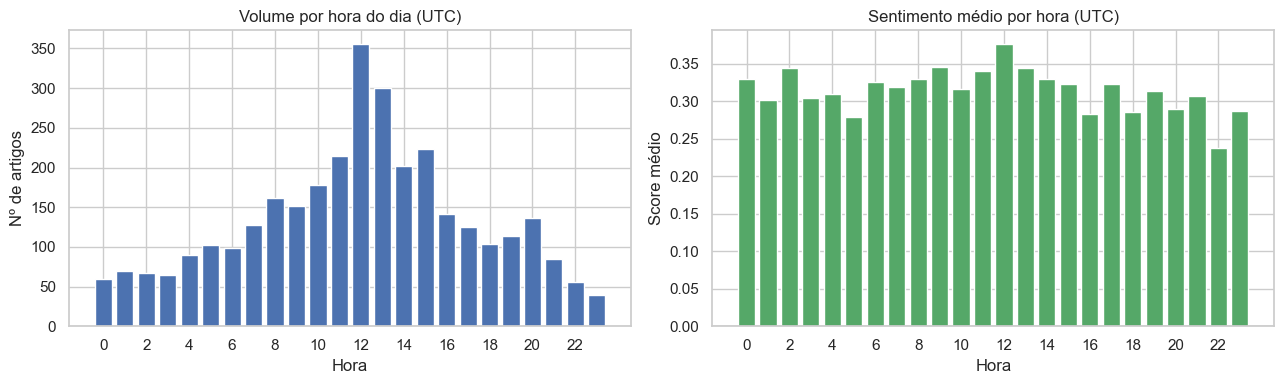

In [26]:
# --- Volume e sentimento por hora do dia ---
df_hour = (
    df.withColumn('hour', F.hour('time_published'))
      .groupBy('hour')
      .agg(F.count('*').alias('artigos'),
           F.avg('overall_sentiment_score').alias('sent_mean'))
      .orderBy('hour')
)
pdf_hour = df_hour.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(pdf_hour['hour'], pdf_hour['artigos'], color='#4C72B0')
axes[0].set_title('Volume por hora do dia (UTC)'); axes[0].set_xlabel('Hora'); axes[0].set_ylabel('Nº de artigos')
axes[0].set_xticks(range(0, 24, 2))
axes[1].bar(pdf_hour['hour'], pdf_hour['sent_mean'], color='#55A868')
axes[1].set_title('Sentimento médio por hora (UTC)'); axes[1].set_xlabel('Hora'); axes[1].set_ylabel('Score médio')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xticks(range(0, 24, 2))
plt.tight_layout(); plt.show()

## 3.3 Detecção de anomalias

Dias cujo volume ou sentimento se desvia do padrão (|z-score| > 2). Sinaliza possíveis eventos de mercado ou falhas de ingestão.

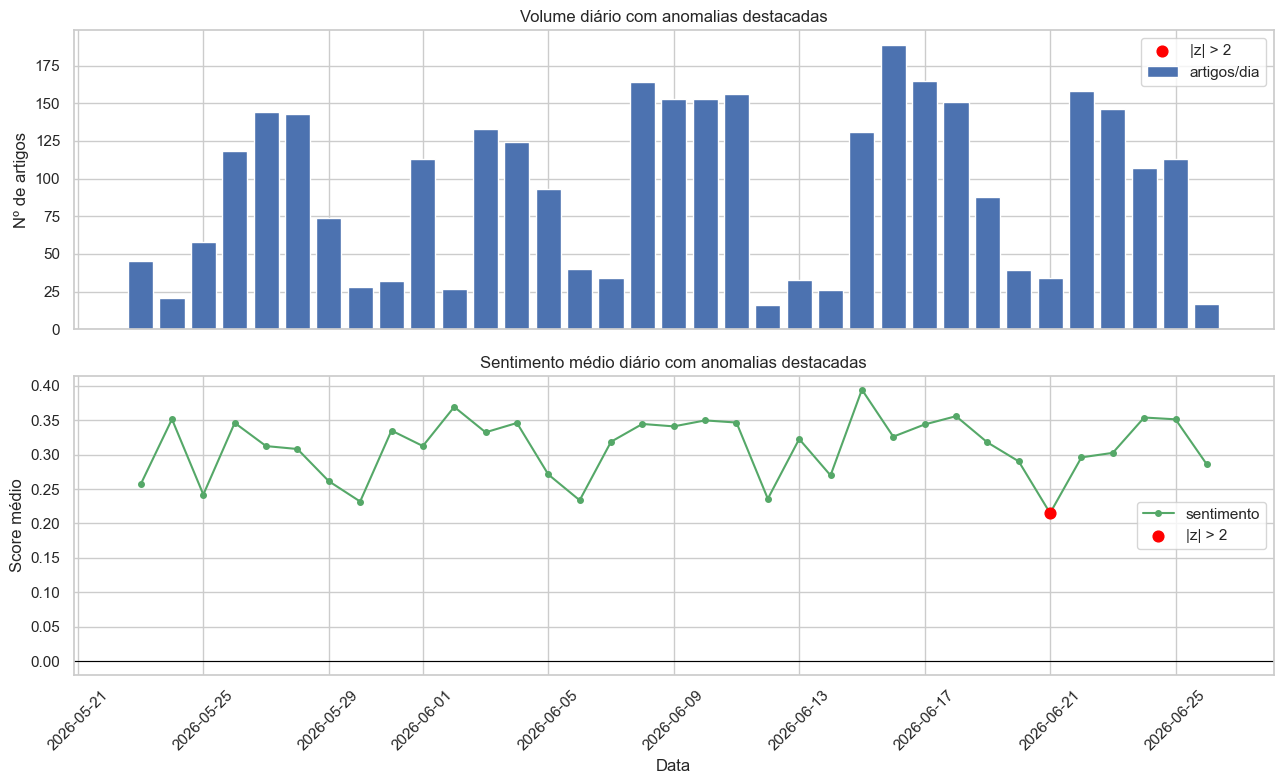

--- Anomalias de volume ---
Empty DataFrame
Columns: [publish_date, n, n_z]
Index: []

--- Anomalias de sentimento ---
publish_date  sent_mean  sent_mean_z
  2026-06-21    0.21507    -2.149005


In [27]:
# --- Z-score de volume e sentimento por dia ---
pdf_anom = pdf_sent.copy()
for col in ['n', 'sent_mean']:
    mu, sigma = pdf_anom[col].mean(), pdf_anom[col].std(ddof=0)
    pdf_anom[f'{col}_z'] = (pdf_anom[col] - mu) / sigma if sigma > 0 else 0

THRESH = 2
anom_vol = pdf_anom[abs(pdf_anom['n_z']) > THRESH].copy()
anom_sent = pdf_anom[abs(pdf_anom['sent_mean_z']) > THRESH].copy()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].bar(pdf_anom['publish_date'], pdf_anom['n'], color='#4C72B0', label='artigos/dia')
axes[0].scatter(anom_vol['publish_date'], anom_vol['n'], color='red', s=60, zorder=5,
               label=f'|z| > {THRESH}')
axes[0].set_title('Volume diário com anomalias destacadas'); axes[0].set_ylabel('Nº de artigos')
axes[0].legend()

axes[1].plot(pdf_anom['publish_date'], pdf_anom['sent_mean'], color='#55A868', marker='o', ms=4, label='sentimento')
axes[1].scatter(anom_sent['publish_date'], anom_sent['sent_mean'], color='red', s=60, zorder=5,
                label=f'|z| > {THRESH}')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Sentimento médio diário com anomalias destacadas')
axes[1].set_ylabel('Score médio'); axes[1].set_xlabel('Data')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

print('--- Anomalias de volume ---')
print(anom_vol[['publish_date', 'n', 'n_z']].to_string(index=False))
print('\n--- Anomalias de sentimento ---')
print(anom_sent[['publish_date', 'sent_mean', 'sent_mean_z']].to_string(index=False))

## 3.4 Decomposição de série e volatilidade (rolling 7 dias)

Decomposição aditiva (tendência + sazonalidade + resíduo) via `statsmodels` e volatilidade do sentimento em janela móvel de 7 dias. Requer preenchimento de datas faltantes (interpolação linear) para a série ficar regular.

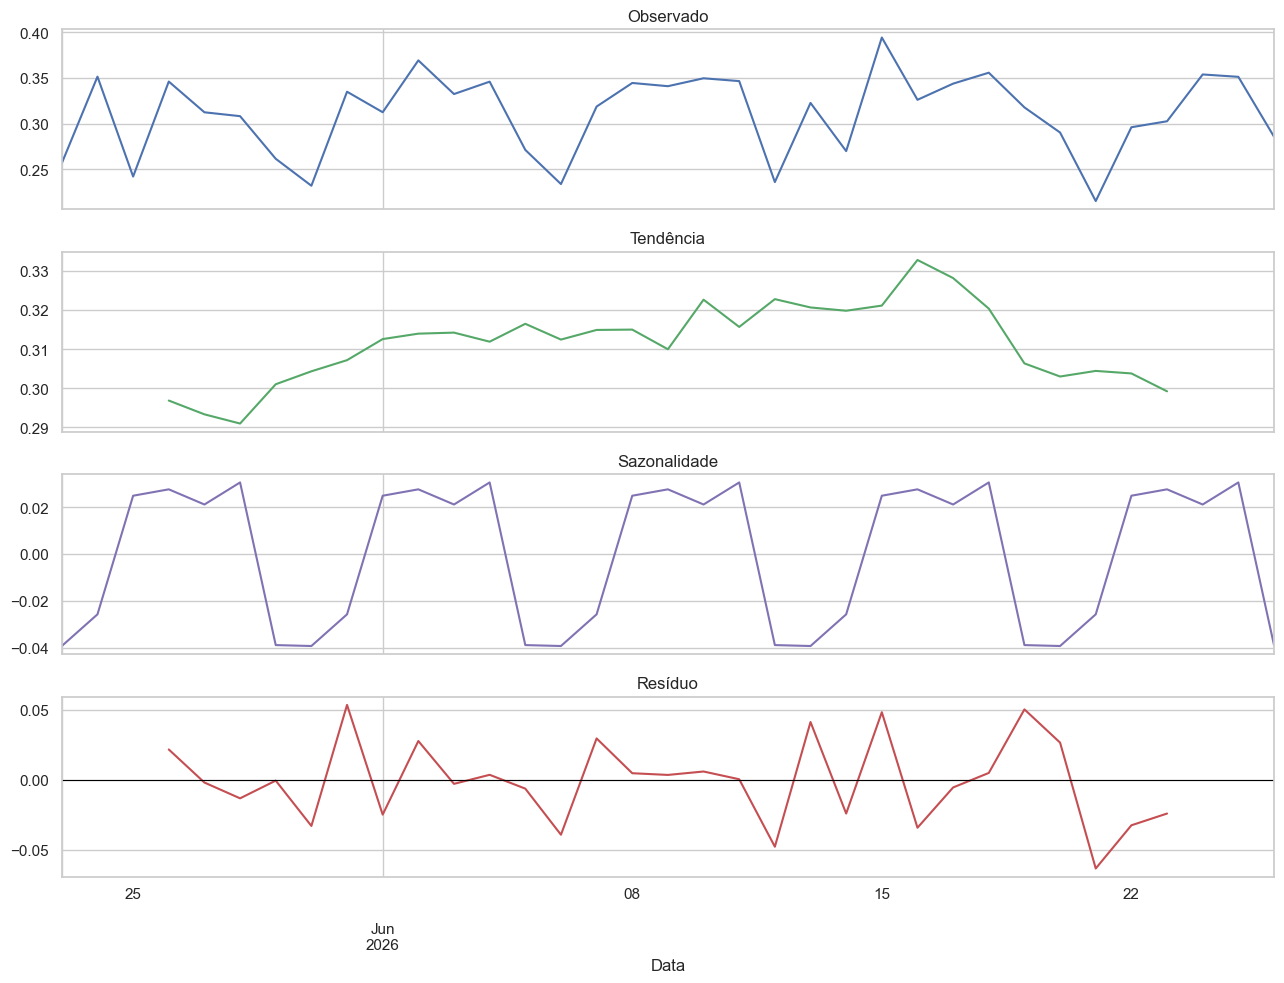

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Série regular diária (preenche datas faltantes com interpolação linear)
ts = pdf_sent.set_index('publish_date')['sent_mean'].asfreq('D').interpolate('linear')

period = min(7, len(ts))  # janela semanal; usa o menor valor se a série for curta
decomp = seasonal_decompose(ts, model='additive', period=period)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
decomp.observed.plot(ax=axes[0], color='#4C72B0', title='Observado')
decomp.trend.plot(ax=axes[1], color='#55A868', title='Tendência')
decomp.seasonal.plot(ax=axes[2], color='#8172B3', title='Sazonalidade')
decomp.resid.plot(ax=axes[3], color='#C44E52', title='Resíduo')
axes[3].axhline(0, color='black', lw=0.8)
axes[3].set_xlabel('Data')
plt.tight_layout(); plt.show()

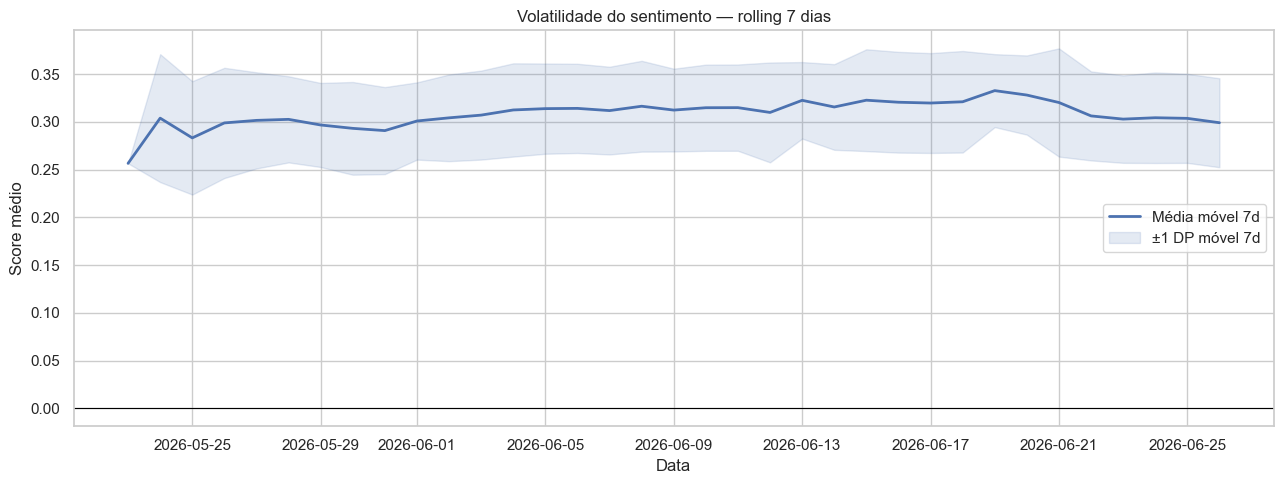

In [29]:
# --- Volatilidade do sentimento (DP móvel 7 dias) ---
roll_window = 7
pdf_roll = pdf_sent.set_index('publish_date').sort_index()
pdf_roll['rolling_mean'] = pdf_roll['sent_mean'].rolling(roll_window, min_periods=1).mean()
pdf_roll['rolling_std'] = pdf_roll['sent_mean'].rolling(roll_window, min_periods=1).std()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(pdf_roll.index, pdf_roll['rolling_mean'], color='#4C72B0', lw=2, label='Média móvel 7d')
ax.fill_between(pdf_roll.index,
                pdf_roll['rolling_mean'] - pdf_roll['rolling_std'].fillna(0),
                pdf_roll['rolling_mean'] + pdf_roll['rolling_std'].fillna(0),
                color='#4C72B0', alpha=0.15, label='±1 DP móvel 7d')
ax.axhline(0, color='black', lw=0.8)
ax.set_title(f'Volatilidade do sentimento — rolling {roll_window} dias')
ax.set_xlabel('Data'); ax.set_ylabel('Score médio')
ax.legend()
plt.tight_layout(); plt.show()

## 1. Análise de Sentimento por Ativo Financeiro (Tickers)

Como a coluna `ticker_sentiment` é um array de objetos (structs), cada artigo pode mencionar várias empresas. 

O primeiro passo é utilizar a função `explode` do PySpark para transformar esse array em múltiplas linhas (uma para cada empresa citada no artigo). Em seguida, podemos extrair as propriedades desse struct para colunas separadas.

In [30]:
# 1. Explodir o array de ticker_sentiment
df_tickers = df.withColumn("ticker_info", F.explode("ticker_sentiment"))

# 2. Extrair os campos estruturados de dentro de cada ticker_info
df_tickers = df_tickers.select(
    "url",
    "time_published",
    "overall_sentiment_score",
    F.col("ticker_info.ticker").alias("ticker"),
    F.col("ticker_info.relevance_score").alias("relevance_score"),
    F.col("ticker_info.ticker_sentiment_score").alias("ticker_sentiment_score"),
    F.col("ticker_info.ticker_sentiment_label").alias("ticker_sentiment_label")
)

# Visualizar o dataframe explodido
df_tickers.limit(5).toPandas()

,url,time_published,overall_sentiment_score,ticker,relevance_score,ticker_sentiment_score,ticker_sentiment_label
0,https://www.jpost.com/israel-news/defense-news...,2026-05-23 23:39:53,0.366356,ESLT,1.000000,0.445150,Bullish
1,https://www.jpost.com/israel-news/defense-news...,2026-05-23 23:39:53,0.366356,GD,0.613270,0.325297,Somewhat-Bullish
2,https://www.insidermonkey.com/blog/jim-cramer-...,2026-05-23 23:22:08,0.397219,TXN,1.000000,0.617016,Bullish
3,https://www.insidermonkey.com/blog/jim-cramer-...,2026-05-23 23:22:08,0.397219,ADI,0.601977,0.135601,Neutral
4,https://simplywall.st/stocks/us/tech/nyse-gpgi...,2026-05-23 22:09:22,0.046691,CMPOV,0.305686,0.045369,Neutral


Com o dataframe explodido, podemos agregar os dados por `ticker`. 

Nesta etapa, podemos calcular o número de vezes que uma empresa foi mencionada (`mentions_count`) e o seu sentimento médio (`avg_sentiment_score`). Podemos também aplicar um filtro (`relevance_score >= 0.5`) para garantir que o artigo é focado nessa empresa, eliminando ruídos de citações passageiras.

In [31]:
# 3. Filtrar menções relevantes e calcular métricas agregadas por ticker
df_ticker_agg = (
    df_tickers
    .filter(F.col("relevance_score") >= 0.5)
    .groupBy("ticker")
    .agg(
        F.count("url").alias("mentions_count"),
        F.round(F.avg("ticker_sentiment_score"), 4).alias("avg_sentiment_score"),
        F.round(F.avg("relevance_score"), 4).alias("avg_relevance_score")
    )
    .filter(F.col("mentions_count") >= 3) # Filtrar tickers muito raros (min. 3 menções)
)

# Top 5 Tickers mais positivos
print("Top 5 Tickers Mais Positivos:")
df_ticker_agg.orderBy(F.col("avg_sentiment_score").desc()).toPandas()

Top 5 Tickers Mais Positivos:


,ticker,mentions_count,avg_sentiment_score,avg_relevance_score
0,ASTC,3,0.7225,1.0000
1,STRL,3,0.6912,1.0000
2,INFQ,5,0.6900,1.0000
3,MANH,4,0.6590,1.0000
4,NVTS,3,0.6567,1.0000
...,...,...,...,...
335,TNC,3,-0.1950,1.0000
336,KODK,3,-0.2137,1.0000
337,NKE,4,-0.2210,0.6199
338,CPB,4,-0.2232,0.6138


# Análise de tópicos

## 4.1 Extração e frequência dos tópicos

A coluna `topics` é um `array<struct<topic, relevance_score>>`. O primeiro passo é explodir o array e extrair os campos, replicando o padrão usado em `ticker_sentiment`.

In [37]:
df_topics = df.withColumn("topic_info", F.explode("topics")).select(
    "url",
    "time_published",
    "overall_sentiment_score",
    "overall_sentiment_label",
    F.col("topic_info.topic").alias("topic"),
    F.col("topic_info.relevance_score").alias("relevance_score"),
)

print(f"Linhas após explode: {df_topics.count()} (artigos originais: {df.count()})")
df_topics.limit(5).toPandas()

Linhas após explode: 11666 (artigos originais: 3321)


,url,time_published,overall_sentiment_score,overall_sentiment_label,topic,relevance_score
0,https://www.jpost.com/israel-news/defense-news...,2026-05-23 23:39:53,0.366356,Bullish,manufacturing,0.871191
1,https://www.jpost.com/israel-news/defense-news...,2026-05-23 23:39:53,0.366356,Bullish,technology,0.746787
2,https://www.jpost.com/israel-news/defense-news...,2026-05-23 23:39:53,0.366356,Bullish,finance,0.639532
3,https://www.insidermonkey.com/blog/jim-cramer-...,2026-05-23 23:22:08,0.397219,Bullish,technology,0.904808
4,https://www.insidermonkey.com/blog/jim-cramer-...,2026-05-23 23:22:08,0.397219,Bullish,earnings,0.849905


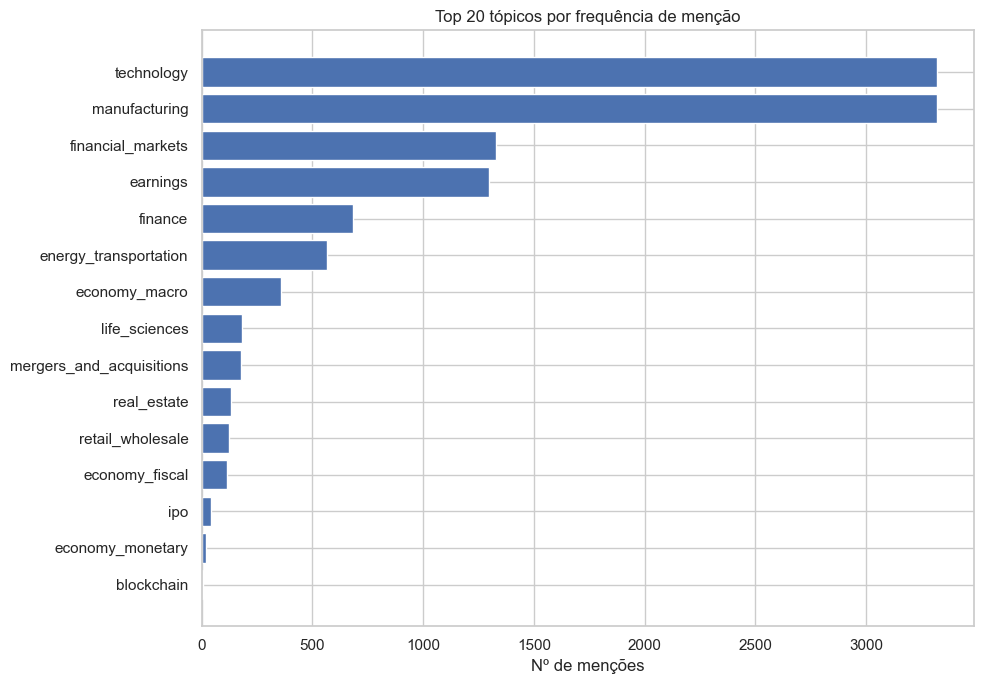

                   topic  mencoes  avg_relevance
              technology     3321         0.8070
           manufacturing     3321         0.7403
       financial_markets     1331         0.8275
                earnings     1295         0.8702
                 finance      684         0.6937
   energy_transportation      565         0.7634
           economy_macro      356         0.6625
           life_sciences      183         0.7710
mergers_and_acquisitions      176         0.8915
             real_estate      131         0.7247
        retail_wholesale      125         0.7111
          economy_fiscal      112         0.6813
                     ipo       40         0.8643
        economy_monetary       19         0.7393
              blockchain        7         0.7312


In [38]:
TOP_N = 20

pdf_topics_freq = (
    df_topics
    .groupBy("topic")
    .agg(
        F.count("url").alias("mencoes"),
        F.round(F.avg("relevance_score"), 4).alias("avg_relevance"),
    )
    .orderBy(F.desc("mencoes"))
    .limit(TOP_N)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(pdf_topics_freq["topic"][::-1], pdf_topics_freq["mencoes"][::-1], color="#4C72B0")
ax.set_title(f"Top {TOP_N} tópicos por frequência de menção")
ax.set_xlabel("Nº de menções")
plt.tight_layout(); plt.show()

print(pdf_topics_freq.to_string(index=False))

## 4.2 Distribuição do relevance_score por tópico

Quão relevante é cada tópico para os artigos em que aparece? Um `relevance_score` próximo de 1 indica que o tópico é central; próximo de 0, que é periférico.

/var/folders/m6/5gldbqjd7y97574965jjjdsw0000gn/T/ipykernel_31437/3581801408.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, patch_artist=True, boxprops=dict(facecolor="#4C72B0", alpha=0.6))


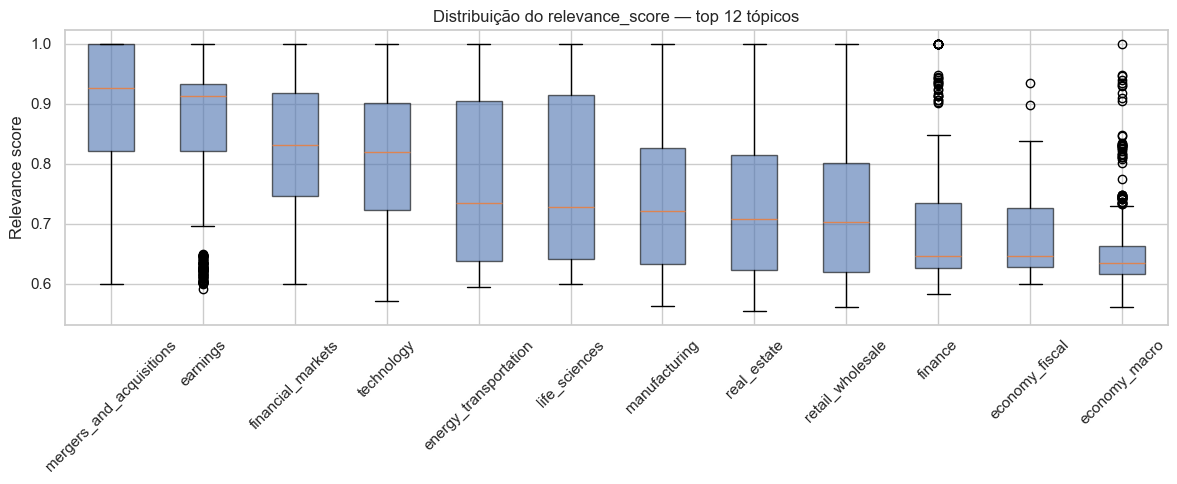

In [39]:
TOP_N_BOX = 12

top_topics_box = [
    r["topic"] for r in
    df_topics.groupBy("topic").count().orderBy(F.desc("count")).limit(TOP_N_BOX).collect()
]

pdf_rel = df_topics.filter(F.col("topic").isin(top_topics_box)).select("topic", "relevance_score").toPandas()
order = pdf_rel.groupby("topic")["relevance_score"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 5))
data = [pdf_rel[pdf_rel["topic"] == t]["relevance_score"].values for t in order]
ax.boxplot(data, labels=order, patch_artist=True, boxprops=dict(facecolor="#4C72B0", alpha=0.6))
ax.set_title(f"Distribuição do relevance_score — top {TOP_N_BOX} tópicos")
ax.set_ylabel("Relevance score")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 4.3 Sentimento médio por tópico

Qual é o sentimento médio (`overall_sentiment_score`) associado a cada tópico? Tópicos com sentimento mais positivo sinalizam cobertura predominantemente otimista naquele tema.

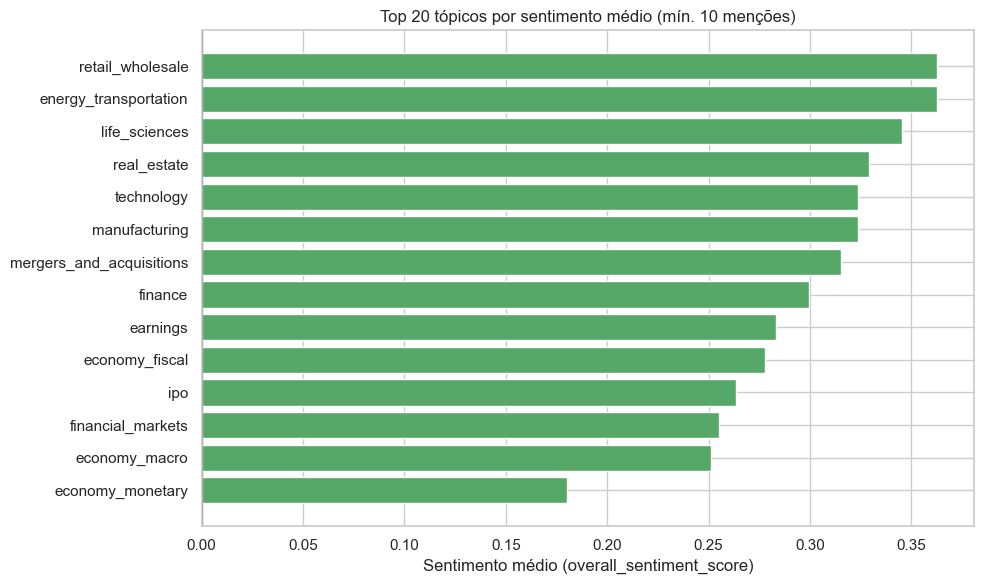

In [40]:
TOP_N_SENT = 20

pdf_sent_topic = (
    df_topics
    .groupBy("topic")
    .agg(
        F.count("url").alias("mencoes"),
        F.round(F.avg("overall_sentiment_score"), 4).alias("avg_sentiment"),
    )
    .filter(F.col("mencoes") >= 10)
    .orderBy(F.desc("avg_sentiment"))
    .limit(TOP_N_SENT)
    .toPandas()
)

colors = ["#55A868" if v >= 0 else "#C44E52" for v in pdf_sent_topic["avg_sentiment"]]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(pdf_sent_topic["topic"][::-1], pdf_sent_topic["avg_sentiment"][::-1], color=colors[::-1])
ax.axvline(0, color="black", lw=0.8)
ax.set_title(f"Top {TOP_N_SENT} tópicos por sentimento médio (mín. 10 menções)")
ax.set_xlabel("Sentimento médio (overall_sentiment_score)")
plt.tight_layout(); plt.show()

## 4.4 Evolução temporal dos principais tópicos

Como a frequência dos top tópicos evoluiu ao longo do tempo? Permite identificar temas em ascensão ou em queda na cobertura noticiosa.

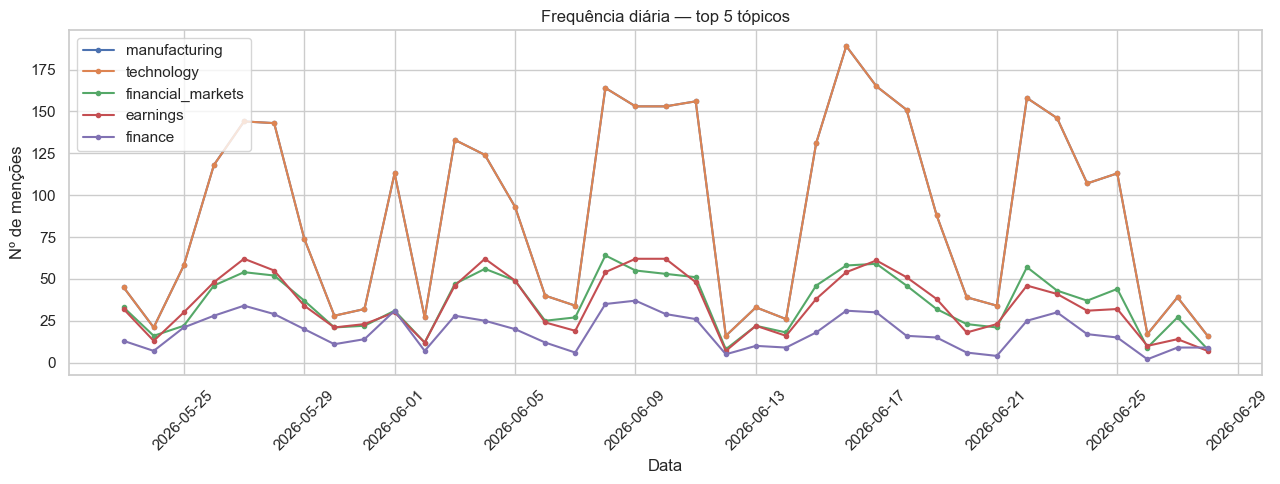

In [41]:
TOP_N_TIME = 5

top_topics_time = [
    r["topic"] for r in
    df_topics.groupBy("topic").count().orderBy(F.desc("count")).limit(TOP_N_TIME).collect()
]

df_topic_time = (
    df_topics
    .filter(F.col("topic").isin(top_topics_time))
    .withColumn("publish_date", F.to_date("time_published"))
    .groupBy("publish_date", "topic")
    .agg(F.count("url").alias("mencoes"))
    .orderBy("publish_date")
)
pdf_tt = df_topic_time.toPandas()
pdf_tt["publish_date"] = pd.to_datetime(pdf_tt["publish_date"])

fig, ax = plt.subplots(figsize=(13, 5))
for topic in top_topics_time:
    subset = pdf_tt[pdf_tt["topic"] == topic]
    ax.plot(subset["publish_date"], subset["mencoes"], marker="o", ms=3, label=topic)
ax.set_title(f"Frequência diária — top {TOP_N_TIME} tópicos")
ax.set_xlabel("Data"); ax.set_ylabel("Nº de menções")
ax.legend(loc="upper left")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()